<p style ="text-align:center">
    <img src="http://epecora.com.br/DataFiles/BannerUFPR.png" width="700" alt="PPGOLD/PPGMNE Python:INTRO"  />
</p>

# DS02_LAB02

## Guilherme Alfredo Kastner

## Objetivos

Use o Jupyter LDS_DecisionTree como base para aplicar a classificação em árvore para os dados neste link.

Explore diferentes valores para os parâmetros do método: 
- max_depth​, 
- min_samples_split​​, 
- min_samples_leaf​​

Entregue um Arquivo Jupyter com a árvore os parâmetros escolhidos e uma análise dos principais nós.

# Case de análise de massa corporal



### Verificar a versão do Python e importar as bibliotecas básicas

In [24]:
# check Python version
!python -V

import pandas as pd # download library to read data into dataframe
import numpy as np # import numpy library
import matplotlib.pyplot as plt # plots
import collections
import random # library for random number generation


from sklearn.tree import DecisionTreeRegressor, plot_tree
import matplotlib.pyplot as plt
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import os

import matplotlib.pyplot as plt

#!conda install python-graphviz --yes
import graphviz


from sklearn.tree import export_graphviz

import itertools


Python 3.10.0


## Importar Arquivo de dados

Inclua um CSV com os dados a serem analisados
 * Incluindo cabeçalho
 * Separação de campos delimitado por *,*
 * Separação de linha usando *nova linha*

 O arquivo tem mais de 12000 registros, pode levar alguns segundos.

In [25]:
print("Data read into dataframe!")

file_path = "H_M_carac.csv"

df = pd.read_csv(file_path)
df.head()

Data read into dataframe!


,altura,peso,idade,massa_muscular,percentual_gordura,tamanho_osseo,capacidade_pulmonar,sexo
0,170.519184,65.817427,18,36.373094,15.738287,4.210713,4.137757,Homem
1,177.874189,76.404266,29,39.792996,15.259102,5.021489,5.015727,Homem
2,162.844031,65.007199,53,32.173814,33.694286,4.435334,3.861206,Mulher
3,162.850003,71.162647,52,29.765095,21.944670,3.931951,4.382248,Mulher
4,178.667237,81.547577,50,42.177731,17.402122,3.774047,6.007130,Homem


## Exibição do DataTable


Para se adequar ao código

In [26]:
# mudando o nome da coluna de Stars para stars
column_names = df.columns.values
print(df.columns.values)

['altura' 'peso' 'idade' 'massa_muscular' 'percentual_gordura'
 'tamanho_osseo' 'capacidade_pulmonar' 'sexo']


## Verificando os dados

 Em um contexto real, deveríamos verificar cada coluna minuciosamente procurando por valores fora dos padrões. Mas aqui vamos "verificar" somente a coluna "stars"

### Exemplos mais comuns de valores fora dos padrões são: 

* Valores numéricos fora do intervalo, por exemplo quantidades de estrelas igual a 15, quando devia ser de 1 a 5.
* Texto no local de valores numéricos
* Valores "nan" Not a Number
* Para valores de categorias, no nosso exemplo os produtos são P1, P2, P3; Caso apareca um "Produto 1" precisa ser uniformizado


In [27]:
df["sexo"].value_counts() # Tabela de frequencia

#print(df["sexo"].mean()) #média das estrelas

c = collections.Counter(df["sexo"]) #frequencia de cada valor
c = sorted(c.items()) 
print(c)

sexo_num = [i[0] for i in c] # todos os possíveis valores que temos em stars
freq = [i[1] for i in c] # todas as frequencias

#print(stars_num)

[('Homem', 300), ('Mulher', 300)]


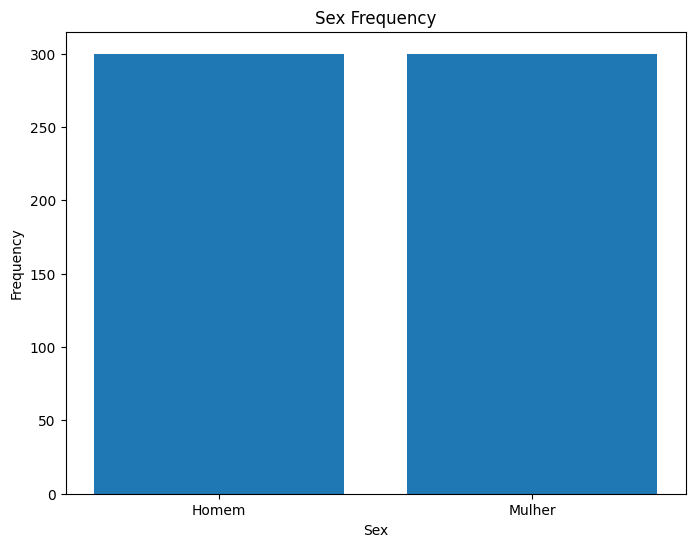

In [28]:
f, ax = plt.subplots(figsize=(8,6))

plt.bar(sexo_num, freq) # visualizando a distribuição

plt.title("Sex Frequency")
plt.xlabel("Sex")
plt.ylabel("Frequency")

plt.show()

## Começando a análise

### Importar as bibliotecas: 
* SKLEARN
* graphviz
* matplotlib


In [29]:
# Adicione o caminho onde está o dot.exe
graphviz_path = r'C:\Program Files\Graphviz\bin'

# Adiciona ao PATH na execução atual do Python
os.environ["PATH"] += os.pathsep + graphviz_path


## Separar o dataFrame em variáveis dependentes e independentes

In [30]:
# split the DataFrame
sexo = df["sexo"] # Só a coluna "stars"
sexo_class = df.drop(columns=['altura', 'peso', 'idade', 'massa_muscular','percentual_gordura', 'tamanho_osseo', 'capacidade_pulmonar']) # Colunas que serão usadas para prever a coluna "stars
variables = df.drop(columns=['sexo']) # Todas as outras colunas com excessão da "stars"

print(sexo_class.head())
variables.head()

     sexo
0   Homem
1   Homem
2  Mulher
3  Mulher
4   Homem


,altura,peso,idade,massa_muscular,percentual_gordura,tamanho_osseo,capacidade_pulmonar
0,170.519184,65.817427,18,36.373094,15.738287,4.210713,4.137757
1,177.874189,76.404266,29,39.792996,15.259102,5.021489,5.015727
2,162.844031,65.007199,53,32.173814,33.694286,4.435334,3.861206
3,162.850003,71.162647,52,29.765095,21.944670,3.931951,4.382248
4,178.667237,81.547577,50,42.177731,17.402122,3.774047,6.007130


## Adequação das variáveis categóricas em colunas binárias - OneHotEncoder




In [31]:
#from sklearn.preprocessing import OneHotEncoder

#enc = OneHotEncoder(sparse_output=False) # problema com sparse_output

# conseguindo todas as colunas categóricas
cat = [i for i in sexo_class.columns if sexo_class[i].dtypes == "O"]


cat_one_hot_list = []
#for i in cat:
#    cat_one_hot_list.append(pd.get_dummies(sexo_class[[i]])) #get_dummies transforma categorias em colunas e codifica binariamente

cat_one_hot_list.append(variables["altura"])
cat_one_hot_list.append(variables["peso"])
cat_one_hot_list.append(variables["idade"])
cat_one_hot_list.append(variables["massa_muscular"])
cat_one_hot_list.append(variables["percentual_gordura"])
cat_one_hot_list.append(variables["tamanho_osseo"])
cat_one_hot_list.append(variables["capacidade_pulmonar"])

var1 = pd.concat(cat_one_hot_list, axis=1) #concatenando horizontamente

#var1.head()

#var1 = var1.drop(columns=['sexo_Mulher']) # removendo uma coluna para evitar multicolinearidade

var1.head()

,altura,peso,idade,massa_muscular,percentual_gordura,tamanho_osseo,capacidade_pulmonar
0,170.519184,65.817427,18,36.373094,15.738287,4.210713,4.137757
1,177.874189,76.404266,29,39.792996,15.259102,5.021489,5.015727
2,162.844031,65.007199,53,32.173814,33.694286,4.435334,3.861206
3,162.850003,71.162647,52,29.765095,21.944670,3.931951,4.382248
4,178.667237,81.547577,50,42.177731,17.402122,3.774047,6.007130


## DecisionTreeClassifier e os seus Parâmetros

O algoritimo do DecisionTreeClassifier tem a tendência natural de fazer um OVERFITING, para ajustar isso modificamos os parâmetros:

* max_depth : Profundidade máxima da árvore
* min_samples_split : quantidade mínima de amostras para se dividir um nó
* min_samples_leaf : Quantidade mínima de amostras em um nó folha (nó da base da árvore)

In [32]:
stree = tree.DecisionTreeClassifier(max_depth = 3, min_samples_split = 20, min_samples_leaf = 10)
stree.fit(var1, sexo_class)

print("Decision tree model saved to delivery_tree!")
print(stree)
print(var1.columns.values)

Decision tree model saved to delivery_tree!
DecisionTreeClassifier(max_depth=3, min_samples_leaf=10, min_samples_split=20)
['altura' 'peso' 'idade' 'massa_muscular' 'percentual_gordura'
 'tamanho_osseo' 'capacidade_pulmonar']


## Resultados em formato gráfico são sempre melhores &#x1F600;

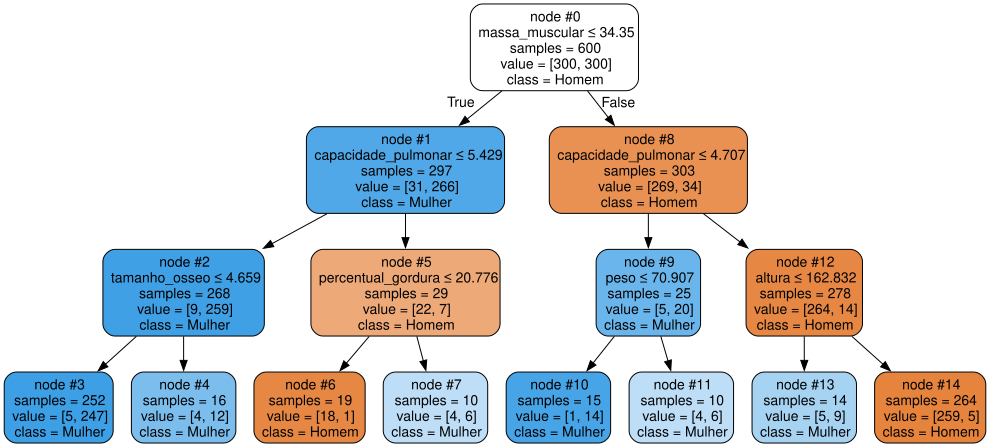

In [33]:
dot_data = export_graphviz(stree,
                feature_names=list(var1.columns.values),
                out_file=None,
                class_names=np.unique(sexo_class.astype(str)),
                filled=True,
                rounded=True,
                node_ids=True,
                special_characters=True,
                impurity=False,
                label="all",
                leaves_parallel = False) #construindo uma visualização da arvore com o graphviz

# Gerando o gráfico direto no Python
graph = graphviz.Source(dot_data)
graph.render("tree_graphviz", format="png", cleanup=True)

# Para visualização
graph

### Parece que os parâmetros de samples e profundidade da árvore mudam a exemplificação gráfica, né?

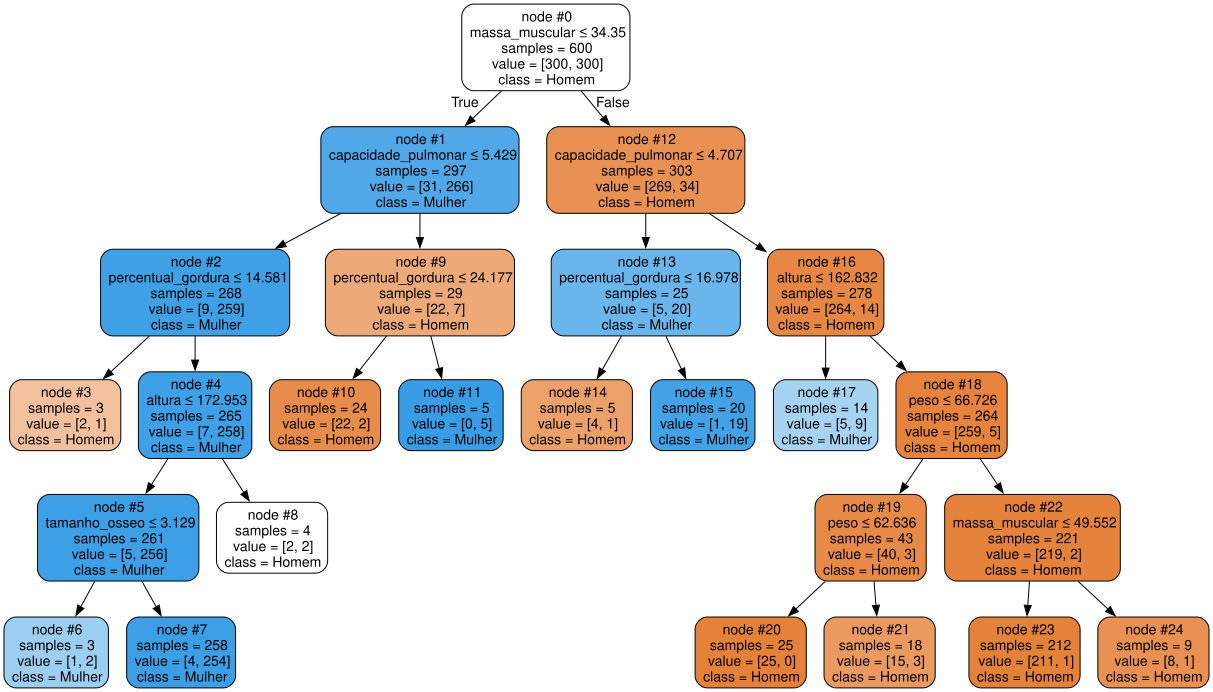

In [35]:
#Podemos construir uma arvore com maior profundidade e explorar cada bifurcação interesante dela

gtree = tree.DecisionTreeClassifier(max_depth = 5, min_samples_split = 25, min_samples_leaf = 3)
gtree.fit(var1, sexo_class)

export_graphviz(gtree,
                feature_names=list(var1.columns.values),
                out_file="delivery_tree.dot",
                class_names=np.unique(sexo_class.astype(str)),
                filled=True,
                rounded=True,
                node_ids=True,
                special_characters=True,
                impurity=False,
                label="all",
                leaves_parallel = False)

with open("delivery_tree.dot") as delivery_tree_image:
    delivery_tree_graph = delivery_tree_image.read()
    
graphviz.Source(delivery_tree_graph)

Algumas conclusões

- A primeira separação ocorre ao categorizar classes de homens e mulheres separando por massa muscular, onde homens costumam ter mais massa. O grupo da direita é predominantemente de homens (269 homens e 34 mulheres)
- No grupo dos homens classificados a direita, a maioria possui uma grande capacidade pulmonar, tanto que das 34 mulheres, essa característica eliminou 20 mulheres.
- Na separação dos grupos dos nós a esquerda, o nós 1 e 9 mostram que boa parte dos homens são localizados através de categorização dos grupos por percentual de gordura e capacidade muscular.

## Fique Conectado

- [![YouTube](https://img.icons8.com/ios-filled/40/000000/youtube-play.png)](https://www.youtube.com/@LigaDataScience/videos)  
  Explore nossos vídeos educacionais e webinars sobre ciência de dados, machine learning e inteligência artificial. Inscreva-se para não perder nenhuma atualização!

- [![LinkedIn](https://img.icons8.com/ios-filled/40/000000/linkedin.png)](https://www.linkedin.com/company/liga-data-science-ufpr/)  
  Siga-nos no LinkedIn para as últimas novidades, oportunidades de carreira e networking profissional no campo da ciência de dados.

- [![Instagram](https://img.icons8.com/ios-filled/40/000000/instagram-new.png)](https://www.instagram.com/ligadatascience/)  
  Confira nosso Instagram para conteúdos dos bastidores, destaques de eventos e o dia a dia da Liga Data Science. Faça parte da nossa jornada!


## Autores

<a href="https://www.linkedin.com/in/eduardopecora/" target="_blank">Eduardo Pecora</a>

<a href="https://www.linkedin.com/in/joão-gabriel-santin-botelho/" target="_blank">João Gabriel</a>

## Referências:

* Documentação da biblioteca <a href="https://pandas.pydata.org/docs/">Pandas</a>
* Documentação do método <a href=https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html>cross_val_score</a>
 * Documentação do método <a href=https://scikit-learn.org/1.5/modules/tree.html>Decision Trees</a>
  
## Log de modificações

| Data | Versão | Modificado por | Descrição |
| ----------------- | ------- | ---------- | ---------------------------------- |
| 04-04-2021       | 1.0     | Eduardo Pecora    | Inicial               |
| 03-11-2021       | 1.1     | Eduardo Pecora    | Estrutura Aula        |
| 27-05-2024       | 1.11     | Eduardo Pecora    | Adequação Scikit-learn        |
| 16-10-2024       | 1.12     | João Gabriel    | Ajustes Gerais      |

&copy; Liga Data Science/UFPR 2024
